# Importing libraries

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score

### Data loading

In [21]:
data = pd.read_csv("./data/winequality-red.csv")

### Data cleaning / Preprocessing

In [22]:
data['good'] = (data['quality'] >= 7).astype(int)  # 1 = good, 0 = bad
data = data.drop(columns=['quality'])

In [23]:
data.isna().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
good                    0
dtype: int64

### Exploratory Data Analysis (EDA) / Visualization

In [24]:
data = data.sort_values('alcohol').reset_index(drop=True)

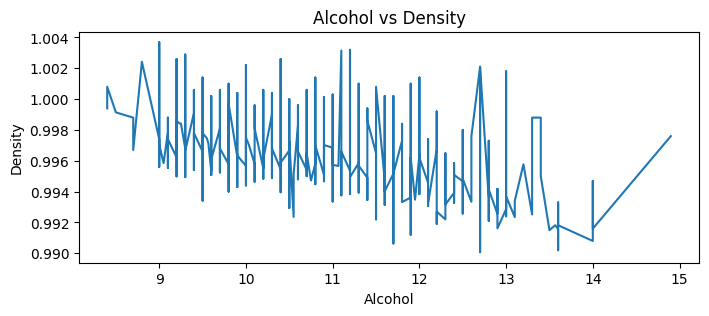

In [25]:
plt.figure(figsize=(8, 3))
plt.plot(data['alcohol'], data['density'])
plt.title("Alcohol vs Density")
plt.xlabel("Alcohol")
plt.ylabel("Density")
plt.show()

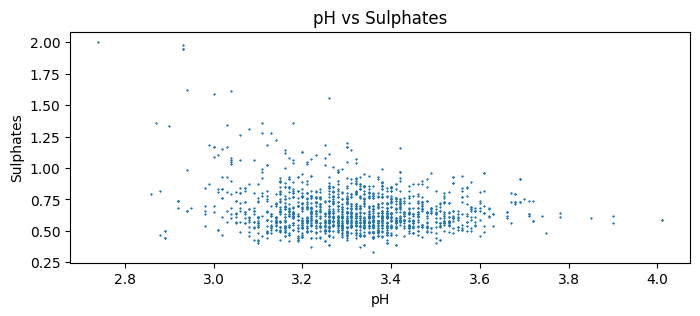

In [26]:
plt.figure(figsize=(8, 3))
plt.plot(data['pH'], data['sulphates'], '*', ms=1)
plt.title("pH vs Sulphates")
plt.xlabel("pH")
plt.ylabel("Sulphates")
plt.show()

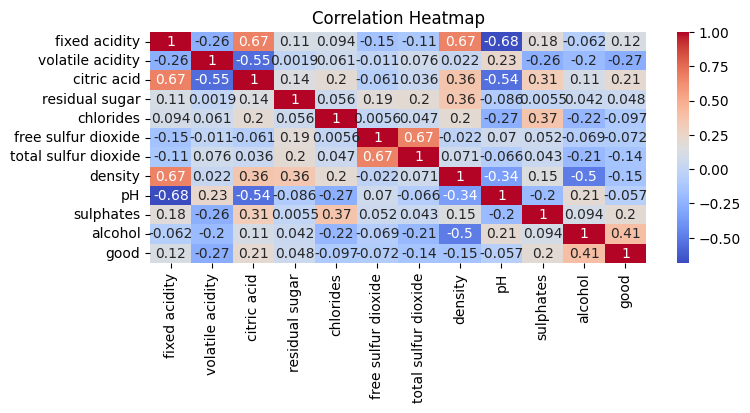

In [27]:
plt.figure(figsize=(8, 3))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


### Independent & Dependent Variables

In [28]:
X = data.drop(columns=['good'])
y = data['good']

### Train-Test Split

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Model Creation & Training

In [30]:
log_reg = Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression(max_iter=2000))])
log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_test)
print("Logistic Regression Results")
print("Accuracy:  ", accuracy_score(y_test, y_pred))
print("Recall:    ", recall_score(y_test, y_pred))
print("Precision: ", precision_score(y_test, y_pred))
print("F1 Score:  ", f1_score(y_test, y_pred))

Logistic Regression Results
Accuracy:   0.884375
Recall:     0.3953488372093023
Precision:  0.6071428571428571
F1 Score:   0.4788732394366197


In [31]:
svc = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LinearSVC(max_iter=20000))
])
svc.fit(X_train, y_train)
y_pred = svc.predict(X_test)
print("Linear SVM Results")
print("Accuracy:  ", accuracy_score(y_test, y_pred))
print("Recall:    ", recall_score(y_test, y_pred))
print("Precision: ", precision_score(y_test, y_pred))
print("F1 Score:  ", f1_score(y_test, y_pred))

Linear SVM Results
Accuracy:   0.89375
Recall:     0.32558139534883723
Precision:  0.7368421052631579
F1 Score:   0.45161290322580644


In [32]:
# Example: Predicting wine quality for a new wine sample

new_wine = [[7.4, 0.7, 0.0, 1.9, 0.076, 11, 34, 0.9978, 3.51, 0.56, 9.4]]

# Predict using the trained Logistic Regression model
prediction = log_reg.predict(new_wine)

if prediction[0] == 1:
    print("The model predicts this wine is GOOD quality")
else:
    print("The model predicts this wine is NOT GOOD quality")


The model predicts this wine is NOT GOOD quality


c:\Users\User\miniconda3\envs\csitB\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
